In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv(
    "../data/train_processed.csv"
)

test_df = pd.read_csv(
    "../data/test_processed.csv"
)

print(train_df.shape)
print(test_df.shape)

(49703, 975)
(12024, 975)


In [3]:
X_train = train_df.drop(
    columns=["ClosePrice"]
)

y_train = train_df["ClosePrice"]

X_test = test_df.drop(
    columns=["ClosePrice"]
)

y_test = test_df["ClosePrice"]

print(X_train.shape)
print(X_test.shape)

(49703, 974)
(12024, 974)


In [4]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Training Complete")

Training Complete


In [5]:
predictions = model.predict(
    X_test
)

predictions[:5]

array([8132168.48493407, 1131686.64195875, 1470661.74594068,
       1548052.43517105,  579714.18778344])

In [6]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print(f"MAE: ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R²: {r2:.4f}")

MAE: $185,742
RMSE: $1,158,377
R²: 0.5235


In [7]:
mape = (
    np.abs(
        (y_test - predictions)
        / y_test
    )
).mean() * 100

print(
    f"MAPE: {mape:.2f}%"
)

MAPE: 22.23%


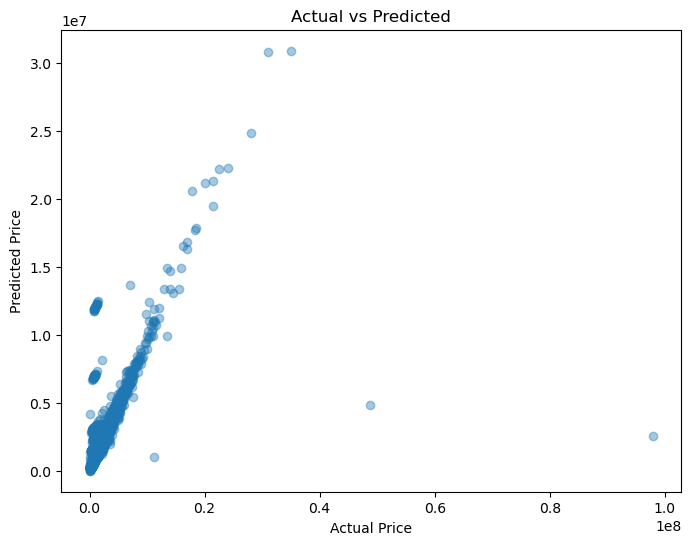

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.4
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted"
)

plt.show()

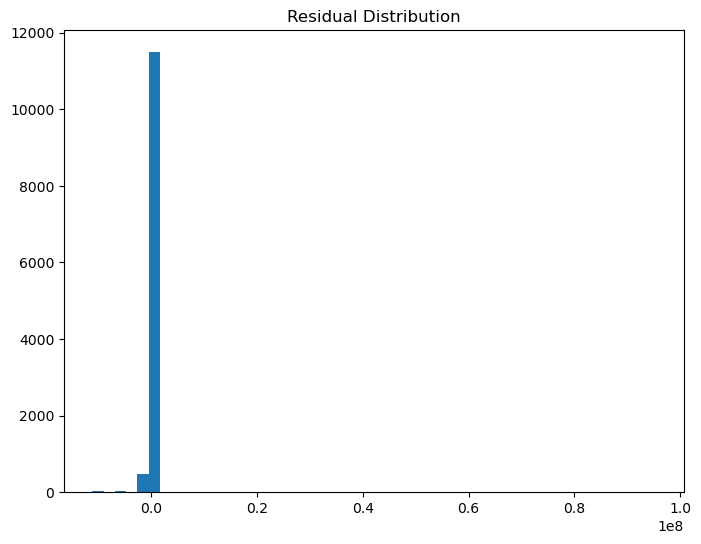

In [9]:
residuals = (
    y_test
    - predictions
)

plt.figure(figsize=(8,6))

plt.hist(
    residuals,
    bins=50
)

plt.title(
    "Residual Distribution"
)

plt.show()

In [10]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

importance = importance.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

importance.head(20)

,Feature,Coefficient
854,City_Valley Center,1.077219e+07
657,City_Ramona,5.833497e+06
404,City_Lake Elsinore,2.511687e+06
157,City_Chula Vista,1.921550e+06
574,City_Oceanside,1.325697e+06
512,City_Montecito,1.229704e+06
861,City_Victorville,1.144588e+06
48,City_Atherton,1.101348e+06
98,City_Bradbury,-8.262192e+05
804,City_Summerland,-7.354369e+05


In [11]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

results["Difference"] = (
    results["Actual"]
    - results["Predicted"]
)

results.head(20)

,Actual,Predicted,Difference
0,8712500.0,8.132168e+06,580331.515066
1,1100000.0,1.131687e+06,-31686.641959
2,1625000.0,1.470662e+06,154338.254059
3,1560000.0,1.548052e+06,11947.564829
4,605000.0,5.797142e+05,25285.812217
5,377500.0,4.050820e+05,-27582.006737
6,400000.0,4.980255e+05,-98025.541987
7,595000.0,6.459626e+05,-50962.638566
8,595000.0,5.855001e+05,9499.858996
9,2400000.0,2.466687e+06,-66686.978763


In [12]:
import joblib

joblib.dump(
    model,
    "../models/linear_regression.pkl"
)

print("Model Saved")

Model Saved


# Week 4 Summary

Built a baseline Linear Regression model.

Evaluation Metrics:

- MAE
- RMSE
- MAPE
- R²

Key Findings:

- Baseline performance established
- Predictions generally follow actual prices
- Some high-value homes remain difficult to predict
- Additional feature engineering may improve performance

Next Steps:

- Compare multiple algorithms
- Explore Random Forest
- Explore XGBoost
- Perform hyperparameter tuning